# Introduction

Notebook ini berisi time series modeling berdasarkan data harga dari pangoly.com.

# Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

from pathlib import Path

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

from pmdarima import auto_arima

# Data Loading

In [2]:
file_path = '../data/pangoly.csv'
raw = pd.read_csv(file_path)

In [3]:
raw['product'].unique()

array(['AM4 AMD B450', 'AM4 AMD B550', 'AM4 AMD X570', 'AM5 AMD B650',
       'AM5 AMD B650E', 'AM5 AMD B840', 'AM5 AMD B850', 'AM5 AMD X670',
       'AM5 AMD X870', 'AM5 AMD X870E', 'LGA1700 Intel B760',
       'LGA1700 Intel Z690', 'LGA1700 Intel Z790', 'LGA1851 Intel B860',
       'LGA1851 Intel H810', 'LGA1851 Intel Z890', 'AM3+ Vishera',
       'AM4 Cezanne', 'AM4 Matisse', 'AM4 Pinnacle Ridge',
       'AM4 Summit Ridge', 'AM4 Vermeer', 'AM5 Granite Ridge',
       'AM5 Phoenix', 'AM5 Raphael', 'LGA1150 Haswell',
       'LGA1151 Coffee Lake', 'LGA1151 Kaby Lake', 'LGA1151 Skylake',
       'LGA1200 Comet Lake', 'LGA1200 Rocket Lake', 'LGA1700 Alder Lake',
       'LGA1700 Raptor Lake', 'LGA1851 Arrow Lake', 'LGA2066 Skylake X',
       'sTR5 Storm Peak', '8GB DDR4', '8GB DDR5', '16GB DDR4',
       '16GB DDR5', '32GB DDR4', '32GB DDR5', '48GB DDR5', '64GB DDR4',
       '64GB DDR5', '96GB DDR5', '128GB DDR5', 'GeForce RTX 3060',
       'GeForce RTX 3060 Ti', 'GeForce RTX 4070 Ti SUPER',

In [4]:
product = 'Radeon RX 9060 XT'

data = raw[raw['product'] == product]
len(data)

446

In [5]:
data.dtypes

date         object
avg         float64
min         float64
max         float64
category     object
product      object
dtype: object

In [6]:
data['date'] = pd.to_datetime(data['date'])

In [7]:
data = data.set_index('date')
data.index = data.index.normalize()
data = data.sort_index()

In [8]:
data.head()

,avg,min,max,category,product
date,,,,,
2025-06-05,384.16,349.99,479.99,GRAPHICS CARDS,Radeon RX 9060 XT
2025-06-06,422.47,349.99,565.99,GRAPHICS CARDS,Radeon RX 9060 XT
2025-06-07,421.51,349.99,549.99,GRAPHICS CARDS,Radeon RX 9060 XT
2025-06-08,397.67,349.99,519.99,GRAPHICS CARDS,Radeon RX 9060 XT
2025-06-09,430.29,349.99,549.99,GRAPHICS CARDS,Radeon RX 9060 XT


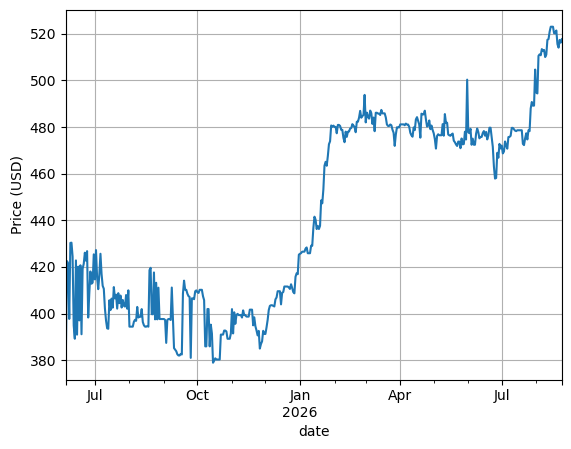

In [9]:
data['avg'].plot(kind='line')
plt.ylabel('Price (USD)')
plt.grid()

# Data Split

In [10]:
len_train = round(len(data) * 0.9)

df_train = data[:len_train]
df_test = data[len_train:]

len(df_train), len(df_test)

(401, 45)

# Model

Kita akan gunakan auto arima mengingat banyak product yang harus dibuat time series forecast nya.

In [13]:
model = auto_arima(df_train['avg'], seasonal=False, stepwise=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2672.966, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2767.939, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2685.523, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2676.457, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2766.327, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2671.027, Time=0.11 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2677.544, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2677.238, Time=0.07 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2672.975, Time=0.19 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=2678.200, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2676.912, Time=0.09 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2674.242, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2670.236, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=2676.681, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]          

# Evaluate

In [21]:
forecast = model.predict(n_periods=45)

In [22]:
forecast_df = pd.DataFrame({'avg': forecast})

In [23]:
forecast_df.head()

,avg
2026-07-11,477.613203
2026-07-12,477.672322
2026-07-13,477.613402
2026-07-14,477.672123
2026-07-15,477.613601


In [24]:
mae = mean_absolute_error(df_test['avg'], forecast_df['avg'])
rmse = np.sqrt(mean_squared_error(df_test['avg'], forecast_df['avg']))

mae, rmse

(21.949248627462108, 28.05167108348058)

## Compare against naive baseline

In [ ]:
def naive_forecast(series, horizon):
    return np.repeat(series.iloc[-1], horizon)

def drift_naive_forecast(series, horizon):
    n = len(series)
    avg_change = (series.iloc[-1] - series.iloc[0]) / (n-1)
    last = series.iloc[-1]
    return np.array([last + avg_change * step for step in range(1, horizon + 1)])

def trend_forecast(series, horizon):
    model = auto_arima(series)
    return model.predict(n_periods=horizon)

def rolling_backtest(series, window, horizon, step=1):
    result = {'naive': [], 'drift_naive': [], 'arima': []}

    for start in range(0, len(series)-window-horizon, step):
        train = series.iloc[start : start+window]
        test = series.iloc[start+window : start+window+horizon]

        preds = {
            'naive': naive_forecast(train, horizon),
            'drift_naive': drift_naive_forecast(train, horizon),
            'arima': trend_forecast(train, horizon)
        }

        for name,ed in preds.items():
            mae = mean_absolute_error(test, pred)
            rmse = np.sqrt(mean_squared_error(test, pred))
            result[name].append((mae, rmse))

    summary = {
        name: {
            'MAE': np.mean([r[0] for r in vals]),
            'RMSE': np.mean([r[1] for r in vals])
        } for name, vals in result.items()
    }

    return summary pr

In [30]:
summary = rolling_backtest(data['avg'], window=90, horizon=10, step=7)
pd.DataFrame(summary)

,naive,drift_naive,arima
MAE,3.549000,2.881371,4.908153
RMSE,3.919703,3.856876,5.555057


Error dari auto arima tidak besar walaupun sedikit lebih besar dengan naive baseline. Kita akan gunakan auto arima pada script terpisah untuk membuat semua model untuk semua product.